# **MARKETING CAMPAIGN ANALYSIS**

### - **DATA VISUALIZATION AND INTERPRETION**

This notebook focuses on data visualization and interpretation aspect of the project "Marketing Campaign Analysis". We are going to plot the data with appropriate chart types and thengenerate some key insights through this data."

###  **Importing Libraries and Loading Data**

This section sets up the environment for analysis by:

1.  **Importing necessary libraries:**
    *   `pandas` for data manipulation.
    *   `seaborn` and `matplotlib.pyplot` for creating static plots.
    *   `plotly.express` (though not used in the subsequent cells shown) for interactive plots.

2.  **Loading the dataset:**
    *   It uses `google.colab.files.upload()` to allow you to upload your data file.
    *   The data is then read into a pandas DataFrame named `df` from a CSV file named "cleaned_data.csv".
    *   `seaborn.set(style="whitegrid")` and `matplotlib.pyplot.rcParams["figure.figsize"]` are used to customize the plot styles and figure size for better visualization.

3.  **Inspecting the data:**
    *   `print(df.columns)` is used to display the names of the columns in the DataFrame, which helps in understanding the structure of the dataset.



In [ ]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Loading cleaned dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("cleaned_data.csv")  # Or the path where your data is
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


Saving cleaned_data.csv to cleaned_data.csv


In [ ]:
print(df.columns)



Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


### **Age Distribution of Customers**

- The first step in understanding the customer base is to analyze their age distribution. In the original dataset, we are given the `Year_Birth` column, which records the year each customer was born. To work with actual age, I created a new column called `Age` by subtracting `Year_Birth` from the current year (2024):

      `Age = 2024 - Year_Birth`

  This transformation helps us interpret the age demographics more intuitively.

- To visualize how the ages are distributed across customers, I used a histogram. A histogram is useful when we want to see how a numerical variable (like age) is spread across its range.

  From the plot, we can identify the most common age ranges, and whether the data is skewed toward any age group.




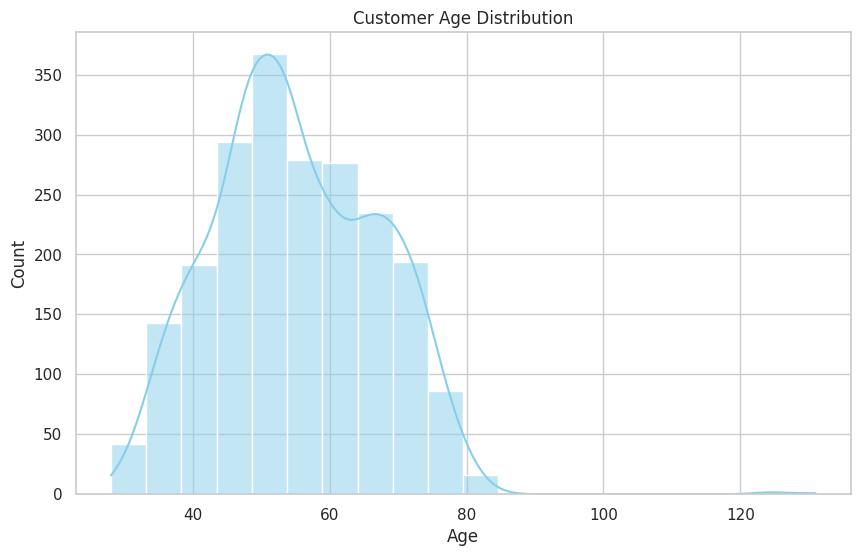

In [ ]:
df['Age'] = 2024 - df['Year_Birth']
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


### ***Insight_1***

**The histogram reveals that the majority of customers fall between the ages of 30 and 60.** There are very few customers below the age of 25 or above 75. This suggests that the marketing campaign is primarily attracting middle-aged individuals, which could help guide future targeting strategies.


## **Customer Income Distribution**

- After analyzing the age distribution, the next important demographic to explore is customer income. Income plays a major role in purchasing behavior and can directly influence how customers respond to marketing campaigns.

- The dataset provides a column named `Income`, which records the annual income of each customer. However, some of the entries in this column are missing (`NaN`). To avoid skewing the results, these null values were dropped before plotting. I chose to use a histogram again because it effectively shows how the income values are distributed.
- By visualizing this distribution, we can get a sense of the economic profile of our customer base, detect any income outliers, and assess whether the company is attracting a specific income segment.




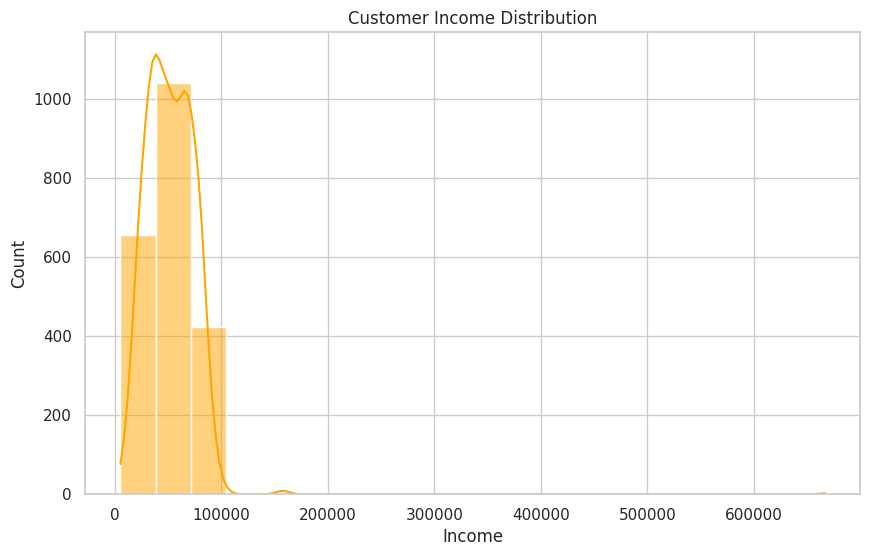

In [ ]:
sns.histplot(df['Income'].dropna(), bins=20, kde=True, color='orange')
plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()


### ***Insight_2***

**The plot shows that most customers earn between 20,000 and 80,000 annually, with a peak around the 50,000 mark**. There are some higher-income individuals in the dataset, but they are relatively few. This indicates that the majority of the customer base belongs to the middle-income segment. Tailoring marketing strategies toward this group could increase effectiveness.



## **Distribution of Total Children in Household**

- Understanding the family structure of customers is essential, as the presence of children can significantly impact purchasing decisions, especially for household goods and products targeted at families.
- I analyzed the distribution of the total number of children in each customer's household. The dataset provides two columns, `Kidhome` and `Teenhome`, indicating the number of kids and teenagers, respectively.
- To get the total number of children, I created a new column `Total_Children` by summing these two columns:

      `Total_Children = Kidhome + Teenhome`

- To visualize this distribution, I used a countplot. A countplot is ideal for showing the counts of observations in each categorical bin. In this case, each bin represents a different total number of children (e.g., 0, 1, 2, 3).
- By visualizing this distribution, we can identify how many customers have no children, one child, two children, or more. This information can help tailor marketing messages and product offerings to families of different sizes.


<ipython-input-15-bc0fab1250ec>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Total_Children', palette='Set2')


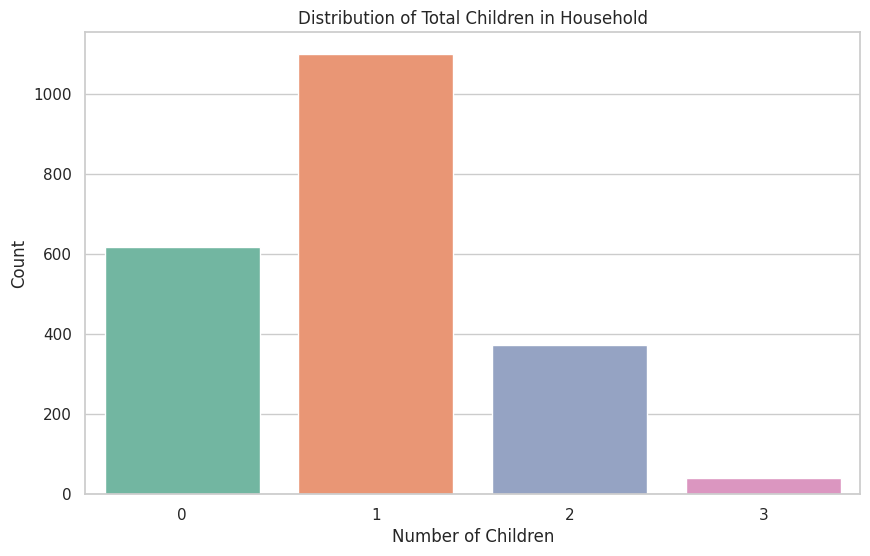

In [ ]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
sns.countplot(data=df, x='Total_Children', palette='Set2')
plt.title('Distribution of Total Children in Household')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.show()


### ***Insight_3***

**The countplot clearly shows that the majority of customers have either 0 or 1 child at home.** The number of households with two or more children drops significantly. This suggests that the marketing campaign might be most effective when targeted at individuals or couples with no children or one child, as they represent the largest segments of the customer base.

## **Total Spending by Product Category**

- To understand which product categories are most popular among customers, I analyzed the total spending on different product types. This helps identify the products that generate the most revenue and those that may require more marketing effort.
- The dataset includes columns representing the amount spent on various product categories: `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, and `MntGoldProds`.
- I summed the spending for each product category across all customers and then sorted these totals to see which categories had the highest total spending.
- To visualize this, I used a bar plot. A bar plot is effective for comparing the total values across different categories. The x-axis represents the total amount spent, and the y-axis shows the product category.
- This visualization allows for a quick comparison of spending patterns across product categories, highlighting which products are driving the most sales.



<ipython-input-16-1db765ff9151>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_totals.values, y=product_totals.index, palette='viridis')


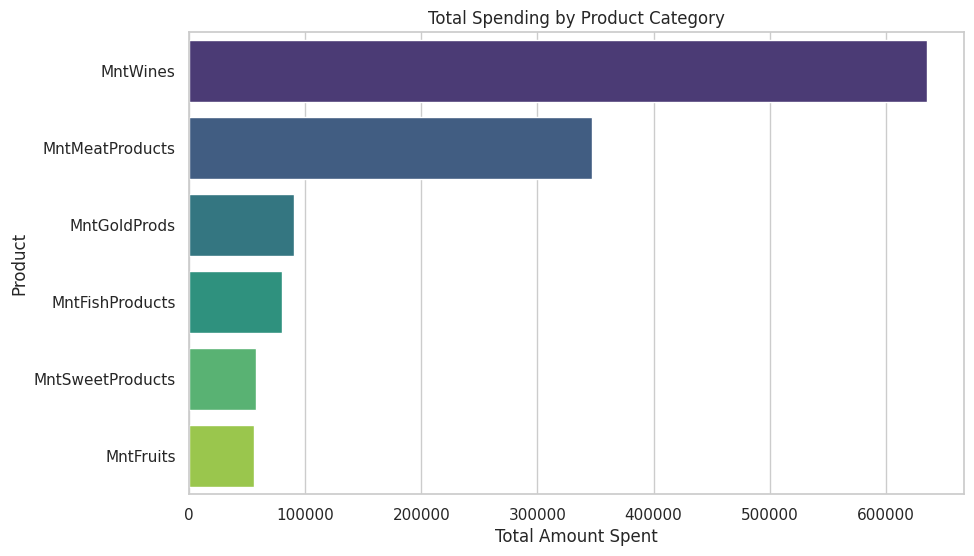

In [ ]:
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
product_totals = df[product_cols].sum().sort_values(ascending=False)

sns.barplot(x=product_totals.values, y=product_totals.index, palette='viridis')
plt.title('Total Spending by Product Category')
plt.xlabel('Total Amount Spent')
plt.ylabel('Product')
plt.show()


### ***Insight_4***

**The bar plot reveals that customers spend the most on Wines, followed by Meat Products and Gold Products.** Spending on Fruits, Fish Products, and Sweet Products is considerably lower. This suggests that wine and meat products are the most popular items among the customer base. Marketing campaigns could capitalize on the popularity of these items while potentially exploring strategies to boost sales for the less popular categories.

## **Total Accepted Campaigns**

- To assess the effectiveness of different marketing campaigns, I analyzed the total number of customers who accepted each campaign. This helps identify which campaigns resonated most with the customer base and which were less successful.
- The dataset includes columns representing whether a customer accepted a specific campaign: `AcceptedCmp1`, `AcceptedCmp2`, `AcceptedCmp3`, `AcceptedCmp4`, and `AcceptedCmp5`. A value of 1 indicates the campaign was accepted, and 0 indicates it was not.
- I summed the values for each campaign column across all customers to get the total number of acceptances for each campaign.
- To visualize this, I used a bar plot. A bar plot is suitable for comparing the total counts for different categories (in this case, the different campaigns). The x-axis represents the campaigns, and the y-axis shows the total number of acceptances.
- This visualization allows for a clear comparison of the success rates of the different marketing campaigns, providing insights into which types of campaigns were most effective.


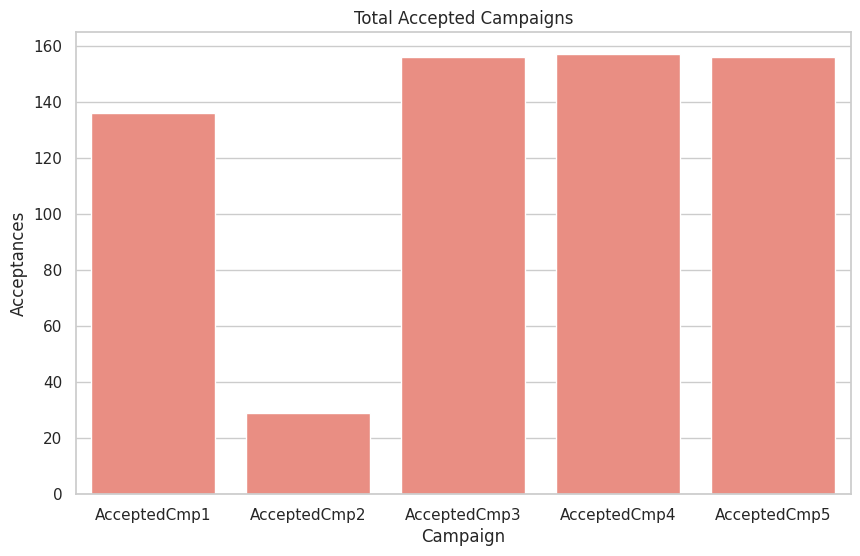

In [ ]:
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
campaign_counts = df[campaigns].sum()

sns.barplot(x=campaign_counts.index, y=campaign_counts.values, color='salmon')
plt.title('Total Accepted Campaigns')
plt.xlabel('Campaign')
plt.ylabel('Acceptances')
plt.show()


### ***Insight_5***

**The bar plot shows the total number of acceptances for each campaign.** By comparing the heights of the bars, we can see which campaigns were most successful in terms of customer acceptance. This information can be used to refine future marketing strategies and allocate resources to campaign types that have proven to be more effective in the past.
Use code with caution
Rate this answer

## **Campaign Response by Marital Status**

- Understanding how different demographic groups respond to marketing campaigns is crucial for targeted marketing. Here, I analyze the campaign response based on the marital status of the customers.
- The dataset contains the `Marital_Status` column, which indicates the marital status of each customer, and the `Response` column, which indicates whether a customer accepted the last marketing campaign (1 for accepted, 0 for not accepted).
- I used a countplot to visualize the number of customers within each marital status category, separated by their response to the last campaign. The `hue` parameter is used to differentiate the bars based on the `Response` column.
- The x-axis represents the different marital statuses, and the y-axis shows the count of customers. Different colored bars within each marital status category indicate the number of customers who responded positively or negatively to the campaign.
- This visualization helps identify which marital status groups are more likely to respond to marketing campaigns, allowing for more focused and effective marketing efforts.

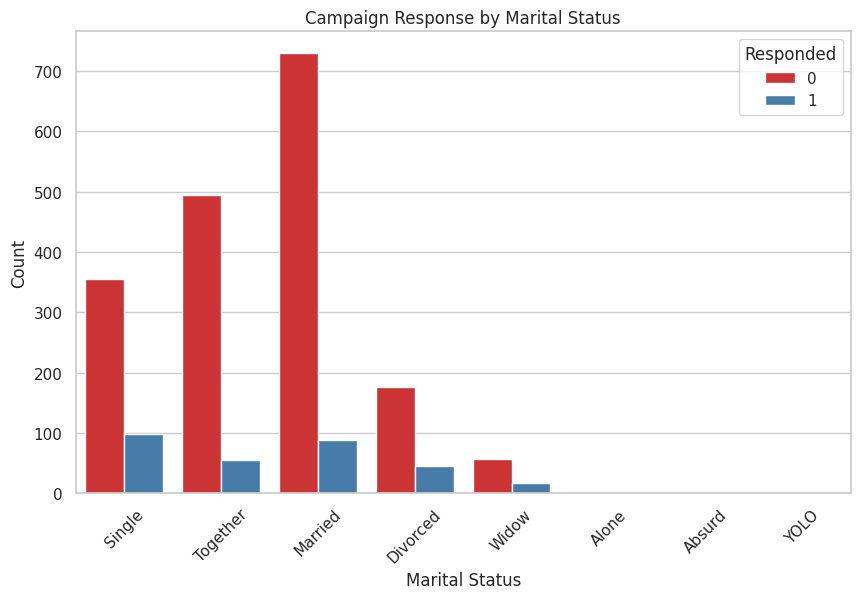

In [ ]:
sns.countplot(data=df, x='Marital_Status', hue='Response', palette='Set1')
plt.title('Campaign Response by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Responded')
plt.show()



### ***Insight_6***

**The countplot provides a comparison of campaign response across different marital statuses.** By examining the counts of "responded" (typically indicated by a different color) for each marital status, we can observe if certain marital groups have a higher acceptance rate for the campaigns. This insight can inform future targeting strategies, potentially focusing on marital statuses that show higher engagement and response rates.

## **Income vs Total Spending (colored by Campaign Response)**

- To explore the relationship between customer income, their total spending, and their response to the last marketing campaign, I created a scatter plot. This visualization can help reveal if there are any patterns in spending habits based on income levels and how these relate to campaign acceptance.
- I calculated the `Total_Spent` for each customer by summing their spending across all product categories.
- The scatter plot uses `Income` on the x-axis and `Total_Spent` on the y-axis. Each point on the plot represents a customer.
- The points are colored based on the `Response` column, allowing us to visually distinguish customers who responded to the last campaign from those who did not.
- Additional customer information such as `Age`, `Education`, and `Marital_Status` is included in the hover data, which can provide more context when interacting with the plot.
- This visualization helps identify potential correlations between income, spending, and campaign response, which can be valuable for segmenting customers and tailoring marketing messages.

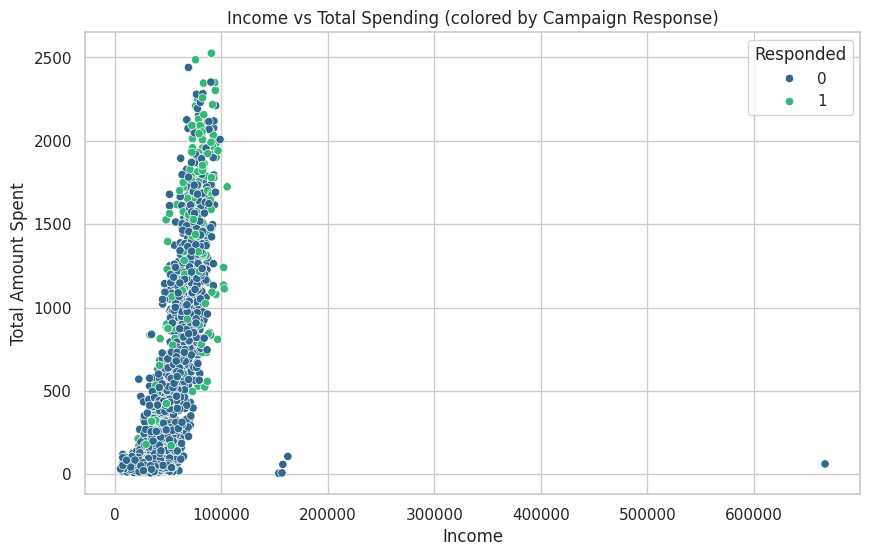

In [ ]:
# Calculating Total_Spent
df['Total_Spent'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Creating the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='Total_Spent', hue='Response', palette='viridis')
plt.title('Income vs Total Spending (colored by Campaign Response)')
plt.xlabel('Income')
plt.ylabel('Total Amount Spent')
plt.legend(title='Responded')
plt.show()

## ***Insight_7***
**The scatter plot suggests a positive correlation between income and total spending.** Generally, customers with higher incomes tend to spend more. Furthermore, customers who responded positively to the marketing campaign appear to be concentrated in higher income brackets and also show higher total spending. This indicates that the campaign was more effective with affluent customers who also have a higher propensity to spend.

## **Data Interpretation and Conclusion**

This analysis of the marketing campaign data provides key insights into the customer base and campaign effectiveness. We explored various aspects, including:

*   **Customer Demographics:** The analysis revealed that the majority of customers are middle-aged (30-60) and fall within the middle-income bracket (20,000 to 80,000 annually). Most households have 0 or 1 child.
*   **Spending Habits:** Customers show a clear preference for Wine and Meat Products, with significantly lower spending on other categories like Fruits and Fish Products.
*   **Campaign Performance:** By examining accepted campaigns and the response to the last campaign based on demographics, we saw that certain campaigns were more successful than others. Notably, customers in higher income brackets who also spent more were more likely to respond positively to the last campaign.

### **Conclusion**

Our marketing campaign is reaching a predominantly middle-aged, middle-income audience. While our customers enjoy Wine and Meat, there's an opportunity to explore strategies to boost engagement with other product categories. The analysis of campaign responses highlights that tailoring our approach based on customer demographics, particularly income and spending levels, can lead to higher acceptance rates. Future campaigns could benefit from a more targeted approach, focusing on the segments that have shown the highest propensity to respond and purchase.